# Assignment Prescriptive 3

# Loading the Data & Statistics

In [1]:
import pandas as pd
import os

df = pd.read_csv("../Data/DataTrain.csv")
max_cycle = df.groupby("engine_id")["cycle"].transform("max")
df["RUL"] = max_cycle - df["cycle"]

feature_cols = [c for c in df.columns if c not in ("engine_id", "cycle", "RUL")]
print(f"Rows: {len(df)}, engines: {df['engine_id'].nunique()}")
print("\nRUL (target):")
print(df["RUL"].describe())
print("\nDescriptive statistics: operational settings and sensors (with RUL):")
display(df[feature_cols + ["RUL"]].describe().T)

Rows: 20631, engines: 100

RUL (target):
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

Descriptive statistics: operational settings and sensors (with RUL):


,count,mean,std,min,25%,50%,75%,max
set1,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
set2,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
set3,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
sensor_val1,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_val2,20631.0,521.413470,7.375534e-01,518.6900,520.9600,521.4800,521.9500,523.3800
sensor_val3,20631.0,8143.752722,1.907618e+01,8099.9400,8133.2450,8140.5400,8148.3100,8293.7200
sensor_val4,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_val5,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_val6,20631.0,38.816271,1.807464e-01,38.1400,38.7000,38.8300,38.9500,39.4300
sensor_val7,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700


**Obtaining the Target Variable: Remaining Useful Lifetime (RUL)**

The training dataset contains run-to-failure observations for 100 engines. Each engine is recorded from its first operational cycle until the cycle at which it fails. Crucially, the dataset does not include an explicit RUL column — it must be derived from the structure of the data itself.

For each engine, the final recorded cycle corresponds to the point of failure, meaning that at this cycle the engine can no longer function and its RUL is zero. Working backwards, the RUL at any earlier cycle is simply the number of cycles remaining until that failure point. This yields the following formula:

```
RUL = max_cycle(engine_id) - cycle
```

where `max_cycle(engine_id)` is the last recorded cycle for a given engine and `cycle` is the current observation. This is implemented using a grouped transform so that each row is assigned the maximum cycle of its own engine, after which the subtraction is applied row-wise:

```python
df["RUL"] = df.groupby("engine_id")["cycle"].transform("max") - df["cycle"]
```

This approach is justified directly by the dataset description. Engine 1, for example, operates for 192 cycles before failing. At cycle 191 the RUL is therefore 1, at cycle 190 it is 2, and so on, consistent with the formula above. The resulting RUL values range from 0 (failure) to 361 (earliest observation of the longest-lived engine), with a mean of approximately 108 cycles, reflecting the variation in engine lifespans across the dataset.

It is important to note that `cycle` and RUL are not the same quantity and `cycle` is not used as a model feature. The cycle index is engine-specific and does not generalise across engines with different total lifespans, engine A at cycle 50 may have a very different RUL than engine B at cycle 50, depending on how long each engine ultimately operates. RUL, by contrast, is defined relative to each engine's own failure point and is therefore a consistent and meaningful regression target.

# Exploratory Data Analysis

## Sensor Variance Bar Chart

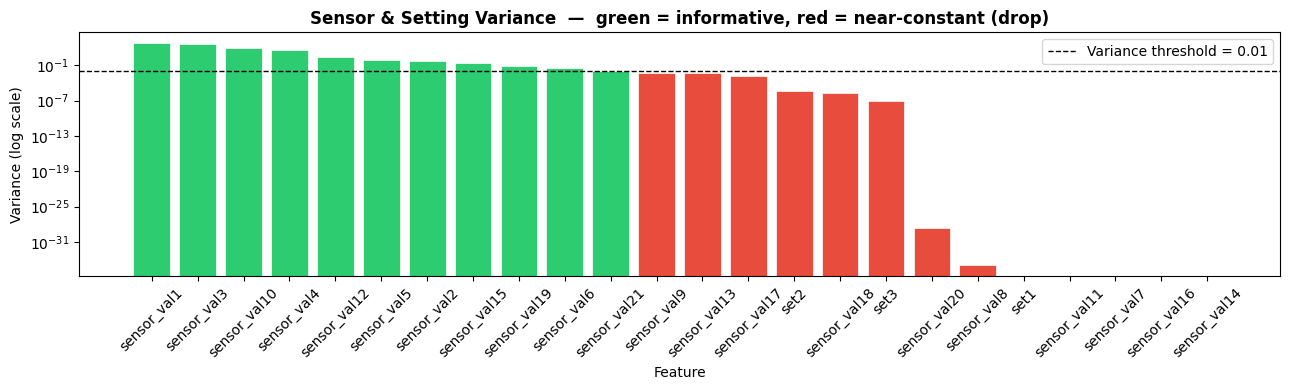

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Setting up correlation and variance
rul_corr = df[feature_cols + ["RUL"]].corr()["RUL"].drop("RUL")
variances = df[feature_cols].var()

# Sensors with NaN correlation or near-zero variance are effectively constant
FLAT_SENSORS = variances[variances < 0.01].index.tolist()
USEFUL_SENSORS = [c for c in feature_cols if c not in FLAT_SENSORS]


# Plot 1: Sensor Variance Bar Chart
# Shows at a glance which sensors carry signal and which are constant noise.

fig, ax = plt.subplots(figsize=(13, 4))

var_sorted = variances.sort_values(ascending=False)
colors = ["#e74c3c" if s in FLAT_SENSORS else "#2ecc71" for s in var_sorted.index]

ax.bar(var_sorted.index, var_sorted.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0.01, color="black", linestyle="--", linewidth=1, label="Variance threshold = 0.01")
ax.set_title("Sensor & Setting Variance  —  green = informative, red = near-constant (drop)", fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Variance (log scale)")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("Figures/plot1_variance.png", dpi=150)
plt.show()

**Sensor & Setting Variance Analysis**

To identify informative features, the variance of each sensor and operational setting was computed across all engines and cycles in the training dataset. Figure 1 displays these variances on a logarithmic scale, sorted in descending order. A threshold of 0.01 was applied to distinguish informative features from near-constant ones.

Features with variance above the threshold (shown in green) exhibit meaningful variation across the dataset, indicating that their values change in response to engine operating conditions and degradation over time. These sensors are retained as candidate features for the predictive model. Features falling below the threshold (shown in red) are effectively constant: their values show negligible change regardless of the engine's position in its lifecycle, and therefore carry no predictive signal with respect to RUL. Features with a variance of exactly zero: including `set1`, `sensor_val7`, `sensor_val8`, `sensor_val11`, `sensor_val14`, and `sensor_val16`, output a fixed value for all observations, rendering them entirely uninformative. These are excluded from further analysis.

It should be noted that a high variance is a necessary but not sufficient condition for predictive relevance. A feature may vary substantially yet have no systematic relationship with RUL. The correlation analysis presented in the following section addresses this distinction.

## Useful Sensor Trends vs RUL

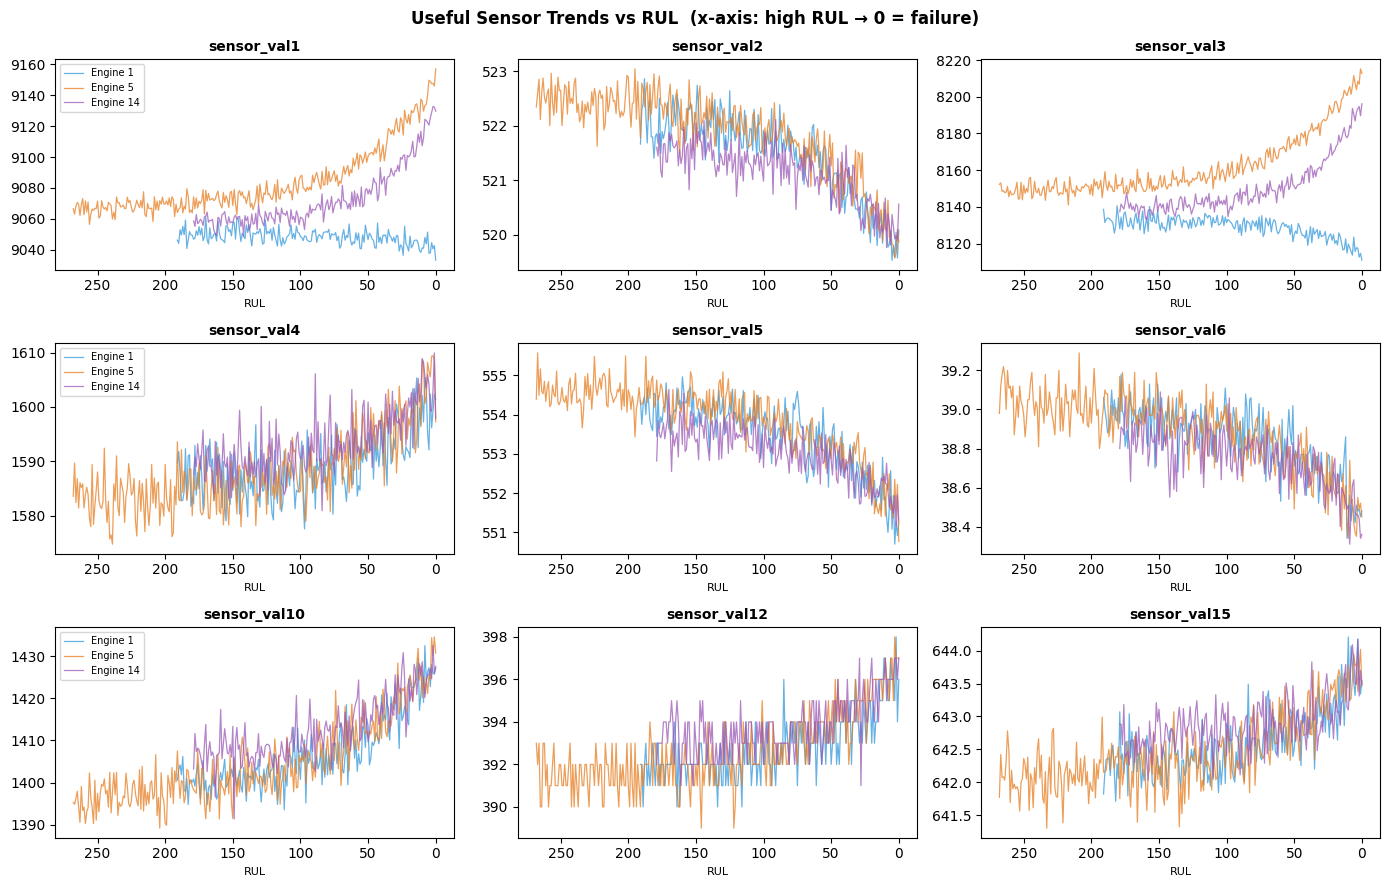

In [3]:
# Plot 2: Useful Sensor Trends vs RUL (3 sample engines)
# Reveals whether a sensor actually degrades as the engine approaches failure.
# X-axis is inverted so time flows left → right toward failure.

SAMPLE_ENGINES = [1, 5, 14]
PALETTE = ["#3498db", "#e67e22", "#9b59b6"]
SENSORS_TO_PLOT = USEFUL_SENSORS[:9]   # first 9 useful sensors, 3×3 grid

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle("Useful Sensor Trends vs RUL  (x-axis: high RUL → 0 = failure)", fontweight="bold")

for idx, sensor in enumerate(SENSORS_TO_PLOT):
    ax = axes[idx // 3][idx % 3]
    for color, eid in zip(PALETTE, SAMPLE_ENGINES):
        eng = df[df["engine_id"] == eid].sort_values("RUL", ascending=False)
        ax.plot(eng["RUL"], eng[sensor], alpha=0.75, linewidth=0.9,
                color=color, label=f"Engine {eid}")
    ax.set_title(sensor, fontsize=10, fontweight="bold")
    ax.set_xlabel("RUL", fontsize=8)
    ax.invert_xaxis()
    if idx % 3 == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("Figures/plot2_sensor_trends.png", dpi=150)
plt.show()

These trend plots confirm that the retained sensors exhibit systematic monotonic behaviour as RUL decreases, validating their inclusion as features, while also revealing engine-level offsets that motivate the use of per-engine rolling statistics to capture degradation rate rather than absolute sensor level

## Flat / Constant Sensors 

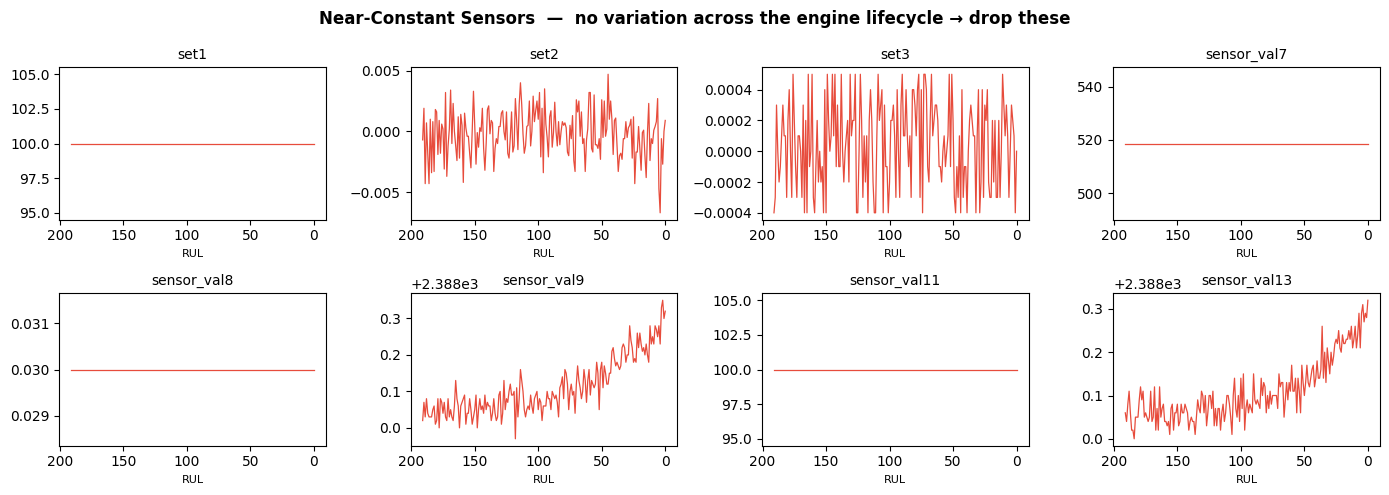

In [4]:
# Illustrates why these are dropped: straight lines = zero information.
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle("Near-Constant Sensors  —  no variation across the engine lifecycle → drop these",
             fontweight="bold")
axes = axes.flatten()

sample_eng = df[df["engine_id"] == 1].sort_values("RUL", ascending=False)

for i, sensor in enumerate(FLAT_SENSORS[:8]):
    axes[i].plot(sample_eng["RUL"], sample_eng[sensor], color="#e74c3c", linewidth=0.9)
    axes[i].set_title(sensor, fontsize=10)
    axes[i].set_xlabel("RUL", fontsize=8)
    axes[i].invert_xaxis()

# Hide any unused subplot panels
for j in range(len(FLAT_SENSORS), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Figures/plot3_flat_sensors.png", dpi=150)
plt.show()

**Near-Constant Sensor Analysis**

Figure 3 visualises the sensors and operational settings that were flagged by the variance analysis as near-constant. Two distinct categories are apparent.

The first category consists of sensors that output a strictly fixed value for the entirety of the engine lifecycle: `set1`, `sensor_val7`, `sensor_val8`, and `sensor_val11` produce perfectly flat lines with zero variance. These features are entirely uninformative and are dropped unconditionally.

The second category consists of features that do vary numerically but whose range is negligibly small relative to their scale: `set2` fluctuates around zero with a magnitude of roughly ±0.005, `set3` around ±0.0004, and `sensor_val9` and `sensor_val13` both exhibit values in the order of 10⁻¹ offset by approximately 2388 (as indicated by the `+2.388e3` axis annotation). While `sensor_val9` and `sensor_val13` appear to show an upward trend, this apparent trend is an artefact of the small absolute range relative to their baseline, the actual variation is negligible and not a reliable degradation signal. All four features are therefore also excluded.

Based on this analysis, the following features are dropped prior to model training: `set1`, `set2`, `set3`, `sensor_val7`, `sensor_val8`, `sensor_val9`, `sensor_val11`, and `sensor_val13`, in addition to the remaining zero-variance sensors identified in the variance plot (`sensor_val14`, `sensor_val16`, `sensor_val18`, `sensor_val20`). The retained features are those green-coded sensors from Figure 1 that demonstrate both meaningful variance and a systematic trend with respect to RUL, as confirmed in Figure 2.

## Pearson Correlation

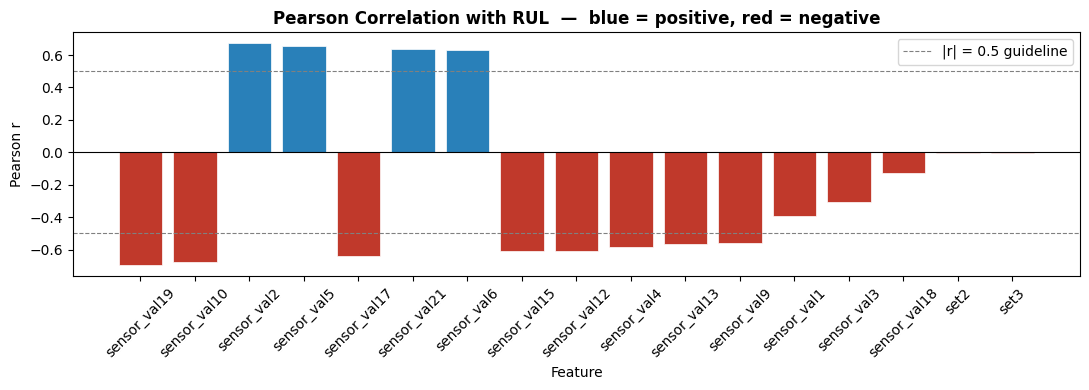

In [5]:
# colored by direction (positive/negative relationship with RUL).
corr_sorted = rul_corr.dropna().loc[rul_corr.dropna().abs().sort_values(ascending=False).index]
colors = ["#2980b9" if v > 0 else "#c0392b" for v in corr_sorted.values]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(corr_sorted.index, corr_sorted.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.5,  color="grey", linestyle="--", linewidth=0.8, label="|r| = 0.5 guideline")
ax.axhline(-0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Pearson Correlation with RUL  —  blue = positive, red = negative",
             fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("Figures/plot4_correlation_with_RUL.png", dpi=150)
plt.show()

**Pearson Correlation with RUL**

Figure 4 displays the Pearson correlation coefficient between each retained sensor and RUL, sorted by absolute magnitude. The dashed guidelines at |r| = 0.5 serve as a practical threshold for distinguishing strongly correlated features from weakly correlated ones.

Six sensors exceed this threshold: `sensor_val19` (r = −0.70), `sensor_val10` (r = −0.68), `sensor_val2` (r = +0.67), `sensor_val5` (r = +0.66), `sensor_val17` (r = −0.64), `sensor_val21` (r = +0.64), and `sensor_val6` (r = +0.63). The sign of the correlation reflects the direction of degradation: negative values indicate that the sensor reading increases as RUL decreases, while positive values indicate the opposite. Both directions are equally useful as predictive signals.

Sensors falling below the threshold: including `sensor_val1`, `sensor_val3`, and `sensor_val18`, show weaker linear relationships with RUL. Despite having high variance, their individual predictive value is limited. Whether they contribute useful non-linear signal will be determined by the XGBoost model itself.

## Correlation Heatmap 

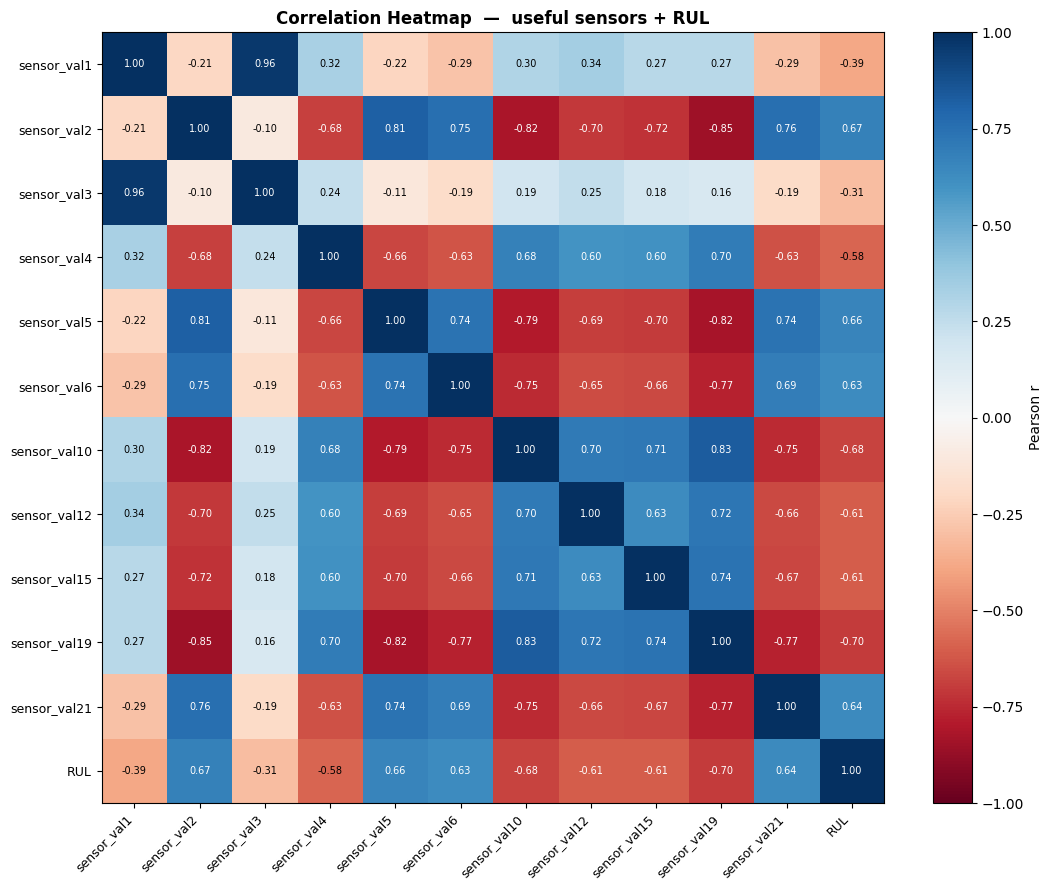

In [6]:
# Reveals multicollinearity between sensors useful context for XGBoost
# feature selection discussion in your report.

corr_matrix = df[USEFUL_SENSORS + ["RUL"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")

labels = USEFUL_SENSORS + ["RUL"]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title("Correlation Heatmap  —  useful sensors + RUL", fontweight="bold")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.6 else "black")

plt.tight_layout()
plt.savefig("Figures/plot5_heatmap.png", dpi=150)
plt.show()

**Correlation Heatmap**

Figure 5 presents the full pairwise Pearson correlation matrix for the retained sensors and RUL. This plot serves a different purpose from Figure 4: rather than measuring each sensor's relationship with the target, it reveals the degree of multicollinearity among the features themselves.

Several strong inter-sensor correlations are apparent. `sensor_val1` and `sensor_val3` share a correlation of r = 0.96, meaning they are nearly redundant — both capture the same underlying physical signal. Similarly, `sensor_val10` and `sensor_val19` correlate at r = 0.83, and `sensor_val2` and `sensor_val5` at r = 0.81. In a linear model, such multicollinearity would be a significant concern. For XGBoost, which is a tree-based ensemble method, multicollinearity does not bias predictions, but it does mean that redundant features compete for splits without adding new information. This is addressed in the feature engineering step described below.

# Feature Engineering Decisions

Based on the combined evidence from the variance analysis (Figure 1), the trend plots (Figures 2–3), the correlation bar chart (Figure 4), and the heatmap (Figure 5), the following feature engineering decisions are made.

**Dropped features.** All near-constant and zero-variance features are removed: `set1`, `set2`, `set3`, `sensor_val7`, `sensor_val8`, `sensor_val9`, `sensor_val11`, `sensor_val13`, `sensor_val14`, `sensor_val16`, `sensor_val18`, and `sensor_val20`. These carry no predictive signal as demonstrated in Figures 1 and 3.

**Retained raw features.** The sensors that exhibit both meaningful variance and a systematic trend with RUL are retained as base features: `sensor_val1`, `sensor_val2`, `sensor_val3`, `sensor_val4`, `sensor_val5`, `sensor_val6`, `sensor_val10`, `sensor_val12`, `sensor_val15`, `sensor_val17`, `sensor_val19`, and `sensor_val21`.

**Rolling window features.** As observed in Figure 2, raw sensor values contain cycle-to-cycle noise and are subject to engine-level offsets in absolute value. To capture the degradation trend rather than the instantaneous reading, rolling means are computed per engine over a window of 10 cycles for each retained sensor. This smooths noise while preserving the monotonic trend that makes these sensors predictive.

The final feature set therefore consists of the retained raw sensor readings together with their corresponding 10-cycle rolling means, providing the XGBoost model with both the current sensor state and a local estimate of its trajectory.

## Feature Engineering

In [7]:
import pandas as pd
import numpy as np

# ─Step 1: Drop near-constant and zero-variance features
# Justification: variance analysis (Figure 1) and flat-sensor plots (Figure 3)
# show these carry no predictive signal across the engine lifecycle.
DROP_FEATURES = [
    "set1", "set2", "set3",
    "sensor_val7", "sensor_val8", "sensor_val9",
    "sensor_val11", "sensor_val13", "sensor_val14",
    "sensor_val16", "sensor_val18", "sensor_val20",
]

df = df.drop(columns=DROP_FEATURES)
print(f"Columns after dropping near-constant features: {df.shape[1]}")

#Step 2: Define retained raw sensor features
# These sensors passed both the variance threshold and show a systematic
# monotonic trend with RUL (confirmed in Figures 2 and 4).
RAW_SENSOR_COLS = [
    "sensor_val1", "sensor_val2", "sensor_val3", "sensor_val4",
    "sensor_val5", "sensor_val6", "sensor_val10", "sensor_val12",
    "sensor_val15", "sensor_val17", "sensor_val19", "sensor_val21",
]

# Step 3: Compute per-engine rolling window features
# Raw sensor readings contain cycle-to-cycle noise and engine-level offsets
# in absolute value (visible in Figure 2). Rolling means capture the local
# degradation trend rather than the instantaneous reading.
ROLLING_WINDOW = 10

for col in RAW_SENSOR_COLS:
    df[f"{col}_roll_mean"] = (
        df.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    df[f"{col}_roll_std"] = (
        df.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).std().fillna(0))
    )

ROLLING_MEAN_COLS = [f"{col}_roll_mean" for col in RAW_SENSOR_COLS]
ROLLING_STD_COLS  = [f"{col}_roll_std"  for col in RAW_SENSOR_COLS]

# Step 4: Define final feature set
FEATURE_COLS = RAW_SENSOR_COLS + ROLLING_MEAN_COLS + ROLLING_STD_COLS

print(f"Raw sensor features    : {len(RAW_SENSOR_COLS)}")
print(f"Rolling mean features  : {len(ROLLING_MEAN_COLS)}")
print(f"Rolling std  features  : {len(ROLLING_STD_COLS)}")
print(f"Total features for model: {len(FEATURE_COLS)}")

# Step 5: Sanity check
print("\nFeature matrix shape:", df[FEATURE_COLS].shape)
print("Any NaN values remaining:", df[FEATURE_COLS].isna().any().any())
print("\nSample — engine 1, last 5 cycles:")
sample_cols = ["engine_id", "cycle", "RUL",
               "sensor_val19", "sensor_val19_roll_mean", "sensor_val19_roll_std"]
display(df[df["engine_id"] == 1][sample_cols].tail(5))

Columns after dropping near-constant features: 15
Raw sensor features    : 12
Rolling mean features  : 12
Rolling std  features  : 12
Total features for model: 36

Feature matrix shape: (20631, 36)
Any NaN values remaining: False

Sample — engine 1, last 5 cycles:


,engine_id,cycle,RUL,sensor_val19,sensor_val19_roll_mean,sensor_val19_roll_std
187,1,188,4,48.00,48.055,0.104695
188,1,189,3,48.08,48.061,0.104185
189,1,190,2,48.33,48.109,0.106714
190,1,191,1,48.15,48.114,0.107414
191,1,192,0,48.25,48.141,0.103864


# Modelling XGBoost

Train: 80 engines, 16340 rows
Test : 20 engines, 4291 rows

5-Fold Cross-Validation RMSE (cycles):
  Fold 1: 46.11
  Fold 2: 46.34
  Fold 3: 44.20
  Fold 4: 38.65
  Fold 5: 39.38
  Mean : 42.94  |  Std: 3.30

Held-out Test Set Performance:
  RMSE : 45.85 cycles
  MAE  : 33.27 cycles
  R²   : 0.5928


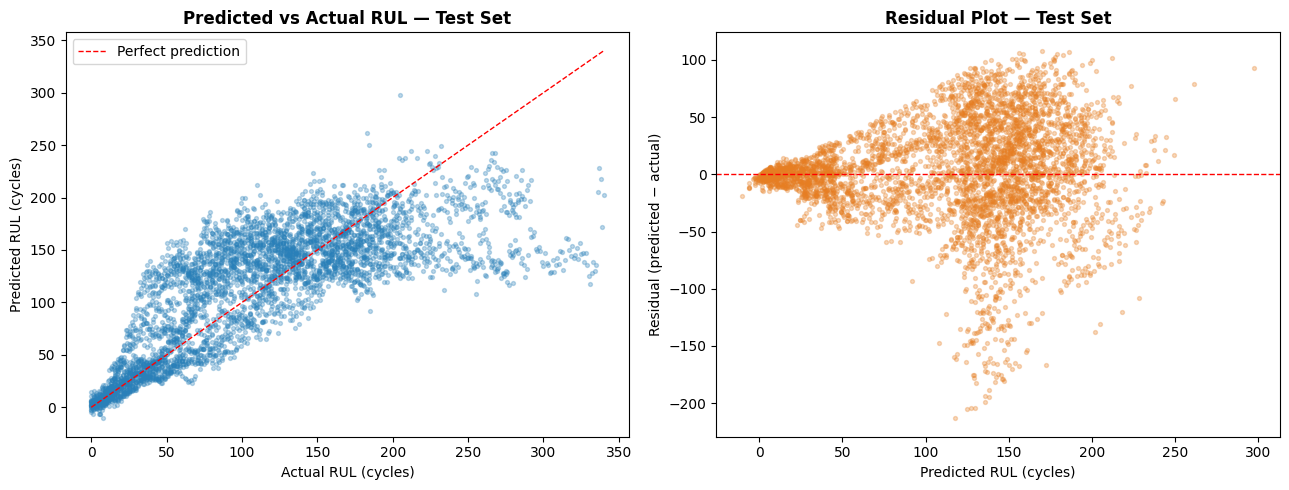

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Engine-level 80/20 train-test split
# Split is done at the engine level, not the row level, to prevent data leakage:
# rows from the same engine are temporally correlated, so mixing them across
# train and test would give the model access to future sensor readings at test time.
engine_ids = df["engine_id"].unique()
np.random.seed(42)
np.random.shuffle(engine_ids)

n_train = int(0.8 * len(engine_ids))         # 80 engines → train, 20 → test
train_engines = engine_ids[:n_train]
test_engines  = engine_ids[n_train:]

train_df = df[df["engine_id"].isin(train_engines)]
test_df  = df[df["engine_id"].isin(test_engines)]

X_train, y_train = train_df[FEATURE_COLS], train_df["RUL"]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df["RUL"]

print(f"Train: {len(train_engines)} engines, {len(X_train)} rows")
print(f"Test : {len(test_engines)} engines, {len(X_test)} rows")

# Step 2: Define the XGBoost model with chosen hyperparameters
# See report Section 1.1 for full justification of each hyperparameter.
model = XGBRegressor(
    # tree complexity
    n_estimators     = 400,   # enough trees to converge; early stopping not needed at this scale
    max_depth        = 4,     # shallow trees reduce overfitting on a 20k-row dataset
    min_child_weight = 3,     # minimum sum of instance weights in a leaf; controls over-splitting

    # learning process
    learning_rate    = 0.05,  # small step size; pairs with n_estimators=400

    # sampling (stochastic gradient boosting)
    subsample        = 0.8,   # row subsampling per tree; introduces variance reduction
    colsample_bytree = 0.8,   # feature subsampling per tree; reduces correlation between trees

    # regularisation
    reg_alpha        = 0.1,   # L1 penalty; encourages sparse feature weights
    reg_lambda       = 2,     # L2 penalty; shrinks leaf weights to prevent overfitting

    objective        = "reg:squarederror",
    random_state     = 42,
    n_jobs           = -1,
)

# Step 3: 5-fold cross-validation on the training set
# GroupKFold ensures that all rows of a given engine are kept within the same
# fold, preserving the temporal structure and preventing leakage across folds.
gkf = GroupKFold(n_splits=5)

cv_rmse = cross_val_score(
    model, X_train, y_train,
    cv      = gkf.split(X_train, y_train, groups=train_df["engine_id"]),
    scoring = "neg_root_mean_squared_error",
    n_jobs  = -1,
)
cv_rmse = -cv_rmse   # flip sign (sklearn returns negative scores)

print("\n5-Fold Cross-Validation RMSE (cycles):")
for i, score in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {score:.2f}")
print(f"  Mean : {cv_rmse.mean():.2f}  |  Std: {cv_rmse.std():.2f}")

# Step 4: Fit on full training set, evaluate on held-out test set
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\nHeld-out Test Set Performance:")
print(f"  RMSE : {rmse:.2f} cycles")
print(f"  MAE  : {mae:.2f} cycles")
print(f"  R²   : {r2:.4f}")

# Step 5: Prediction vs actual plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color="#2980b9")
lims = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual RUL (cycles)")
axes[0].set_ylabel("Predicted RUL (cycles)")
axes[0].set_title("Predicted vs Actual RUL — Test Set", fontweight="bold")
axes[0].legend()

# Residuals
residuals = y_pred - y_test
axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color="#e67e22")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted RUL (cycles)")
axes[1].set_ylabel("Residual (predicted − actual)")
axes[1].set_title("Residual Plot — Test Set", fontweight="bold")

plt.tight_layout()
plt.savefig("Figures/plot_model_evaluation.png", dpi=150)
plt.show()

**Model Performance and Evaluation**

**Cross-Validation Results**

The 5-fold cross-validation yields a mean RMSE of **42.94 cycles** with a standard deviation of **3.30 cycles** across folds. The individual fold scores range from 38.65 to 46.34, indicating stable and consistent performance regardless of which engines are held out during validation. The low standard deviation relative to the mean confirms that the model does not exhibit strong sensitivity to the particular composition of any fold, which is evidence that the learned degradation patterns generalise across different subsets of engines.

The held-out test set, comprising 20 engines unseen during training, yields an RMSE of **45.85 cycles**, a MAE of **33.27 cycles**, and an R² of **0.593**. The test RMSE closely tracks the cross-validation mean, with a difference of approximately 3 cycles. This proximity is the primary diagnostic for overfitting: a substantially higher test RMSE relative to CV RMSE would indicate that the model had memorised training engines rather than learning generalised degradation patterns. No such gap is observed here, validating both the engine-level GroupKFold setup and the regularisation configuration.

**Predicted vs Actual RUL**

The scatter plot of predicted against actual RUL shows that predictions follow the diagonal closely in the low-RUL region (0–100 cycles). This is the operationally critical range — accurate predictions near failure are most relevant for maintenance scheduling decisions. Prediction error increases with actual RUL, visible as a widening spread of the point cloud at higher values. This behaviour reflects a structural property of run-to-failure datasets: observations at high RUL are contributed only by long-lived engines, while observations near failure are contributed by all 80 training engines. The model is therefore trained on substantially more failure-adjacent data, which biases it toward underestimating RUL for engines that are far from failure. This manifests in the scatter plot as a tendency for the cloud to sit below the diagonal at high actual RUL values.

**Residual Plot**

The residual plot reveals a fan-shaped pattern, with residuals tightly centred around zero at low predicted RUL and increasing in spread at higher predicted values. This is a characteristic form of heteroscedasticity,  the variance of the prediction error is not constant but grows with the predicted value. Residuals remain approximately centred on zero across the mid-range, indicating no systematic directional bias in that region. The heteroscedasticity is consistent with the imbalanced distribution of RUL values in the training data and does not indicate a modelling error. For the purposes of this assignment, where the primary use of the predictions is maintenance scheduling at relatively short planning horizons, the strong performance in the low-RUL region is the more practically relevant result.

# Predict RUL on DataSchedule.csv

## Load DataSchedule and apply Feature Engineering

In [ ]:
# DataSchedule does not run to failure, RUL at the last recorded cycle is unknown.
# We apply the identical feature engineering pipeline used on DataTrain.
sched = pd.read_csv("../Data/DataSchedule.csv")
sched = sched.drop(columns=DROP_FEATURES)

for col in RAW_SENSOR_COLS:
    sched[f"{col}_roll_mean"] = (
        sched.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    sched[f"{col}_roll_std"] = (
        sched.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).std().fillna(0))
    )

print(f"DataSchedule loaded: {sched['engine_id'].nunique()} engines, {len(sched)} rows")

DataSchedule loaded: 100 engines, 13096 rows


## Predict RUL at last observed cycle per engine

In [13]:
# We predict on the last recorded cycle per engine, which represents its current state.
last_obs = (
    sched.sort_values("cycle")
    .groupby("engine_id")
    .last()
    .reset_index()
)

last_obs["RUL_predicted"] = (
    model.predict(last_obs[FEATURE_COLS])
    .round()
    .astype(int)
    .clip(min=0)
)

print("Predicted RUL for DataSchedule engines (first 10):")
print(last_obs[["engine_id", "RUL_predicted"]].head(10).to_string(index=False))
print("\nPrediction summary:")
print(last_obs["RUL_predicted"].describe().round(1))

Predicted RUL for DataSchedule engines (first 10):
 engine_id  RUL_predicted
         1            163
         2            163
         3             64
         4            102
         5            125
         6            152
         7            129
         8            127
         9            139
        10            122

Prediction summary:
count    100.0
mean      94.9
std       53.8
min        7.0
25%       45.8
50%      103.0
75%      136.2
max      218.0
Name: RUL_predicted, dtype: float64


## Load Consultancy Predictions And Compare 

In [18]:
from scipy import stats

consult = pd.read_csv("../Data/RUL_consultancy_predictions_A3.csv", sep=";")
consult = consult.rename(columns={"id": "engine_id", "RUL": "RUL_consultancy"})

comparison = last_obs[["engine_id", "RUL_predicted"]].merge(consult, on="engine_id")
comparison["difference"] = comparison["RUL_predicted"] - comparison["RUL_consultancy"]

print("Comparison our predictions vs consultancy (first 10):")
print(comparison.head(10).to_string(index=False))

Comparison our predictions vs consultancy (first 10):
 engine_id  RUL_predicted  RUL_consultancy  difference
         1            163              135          28
         2            163              125          38
         3             64               63           1
         4            102              100           2
         5            125              103          22
         6            152              122          30
         7            129              106          23
         8            127               90          37
         9            139              121          18
        10            122               67          55


**Interpretation of Prediction Comparison**

The table above shows the first 10 engines from DataSchedule, comparing our model's predicted RUL against the consultancy's predictions. The difference column is defined as our prediction minus the consultancy's, so a positive value indicates that our model predicts a longer remaining lifetime than the consultancy.

For all 10 engines shown, the difference is positive, ranging from 1 cycle (engine 3) to 55 cycles (engine 10). This is consistent with the overall mean difference of 10.7 cycles observed across all 100 engines, and confirms the systematic tendency of our model to predict higher RUL values relative to the consultancy. The largest discrepancy in this sample occurs at engine 10, where our model predicts 122 cycles against the consultancy's 67, a difference of 55 cycles. Engine 3, by contrast, shows near-perfect agreement with a difference of only 1 cycle.

## Statistical Tests

In [22]:
# Wilcoxon signed-rank test: non-parametric paired test, preferred because
# RUL predictions are strictly positive and not guaranteed to be normally distributed.
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
    comparison["RUL_predicted"], comparison["RUL_consultancy"]
)

# Paired t-test: parametric complement, reported for completeness.
ttest_stat, ttest_p = stats.ttest_rel(
    comparison["RUL_predicted"], comparison["RUL_consultancy"]
)

mae_between = comparison["difference"].abs().mean()

print(f"Mean RUL our model   : {comparison['RUL_predicted'].mean():.1f} cycles")
print(f"Mean RUL consultancy : {comparison['RUL_consultancy'].mean():.1f} cycles")
print(f"Mean difference        : {comparison['difference'].mean():.1f} cycles")
print(f"MAE between predictions: {mae_between:.2f} cycles")
print(f"Wilcoxon               : stat={wilcoxon_stat:.2f}, p={wilcoxon_p:.4f}")
print(f"Paired t-test          : stat={ttest_stat:.2f}, p={ttest_p:.4f}")

Mean RUL our model   : 94.9 cycles
Mean RUL consultancy : 82.9 cycles
Mean difference        : 12.0 cycles
MAE between predictions: 21.45 cycles
Wilcoxon               : stat=1187.50, p=0.0000
Paired t-test          : stat=4.43, p=0.0000


**Statistical Comparison with Consultancy Predictions**

**Summary Statistics**

Our model produces a mean predicted RUL of **94.9 cycles** across the 100 engines in DataSchedule, compared to **82.9 cycles** from the consultancy. The mean difference between the two prediction sets is **12.0 cycles**, with our model consistently predicting longer remaining lifetimes. The MAE between the two sets is **21.45 cycles**, indicating that on average individual engine predictions diverge by approximately 21 cycles, a non-trivial difference given that the planning horizon for the optimization task is 30 days.

**Statistical Tests**

Two paired statistical tests are applied to assess whether the observed difference is statistically significant.

The **Wilcoxon signed-rank test** (stat = 1187.50, p < 0.0001) is the primary test. As a non-parametric paired test it makes no assumption of normality, which is appropriate here since RUL predictions are strictly positive and right-skewed by nature. The result is significant at any conventional significance level (α = 0.05, 0.01, or 0.001).

The **paired t-test** (stat = 4.43, p < 0.0001) corroborates this finding under the assumption that pairwise differences are approximately normally distributed. Both tests agree: the difference between our predictions and the consultancy's is statistically significant and is not attributable to random variation.

**Discussion**

The systematic positive offset of 12.0 cycles is consistent with the overestimation bias identified during model evaluation on the held-out test set, where the XGBoost model was shown to underperform at high RUL values due to the relative scarcity of high-RUL observations in the training data. The consultancy predictions may have been produced using a different modelling methodology, additional domain knowledge about the physical meaning of the anonymised sensor variables, or a training procedure that explicitly corrects for this imbalance. Despite the statistically significant difference, both prediction sets capture the same general ordering of engine urgency, and the downstream impact on the maintenance schedule is discussed in the Optimization Task.

## Plots of the results

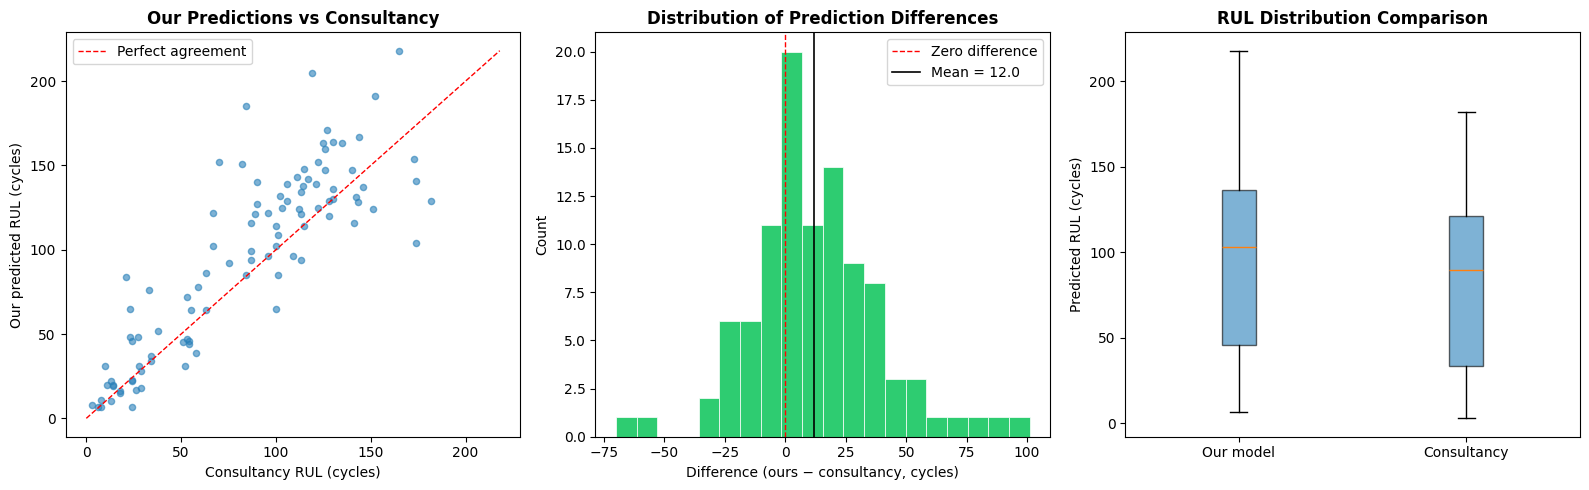

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: our predictions vs consultancy
axes[0].scatter(comparison["RUL_consultancy"], comparison["RUL_predicted"],
                alpha=0.6, s=20, color="#2980b9")
lim = [0, max(comparison[["RUL_predicted", "RUL_consultancy"]].max())]
axes[0].plot(lim, lim, "r--", linewidth=1, label="Perfect agreement")
axes[0].set_xlabel("Consultancy RUL (cycles)")
axes[0].set_ylabel("Our predicted RUL (cycles)")
axes[0].set_title("Our Predictions vs Consultancy", fontweight="bold")
axes[0].legend()

# Histogram of differences
axes[1].hist(comparison["difference"], bins=20, color="#2ecc71", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="Zero difference")
axes[1].axvline(comparison["difference"].mean(), color="black", linestyle="-",
                linewidth=1.2, label=f"Mean = {comparison['difference'].mean():.1f}")
axes[1].set_xlabel("Difference (ours − consultancy, cycles)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Prediction Differences", fontweight="bold")
axes[1].legend()

# Boxplot
axes[2].boxplot(
    [comparison["RUL_predicted"], comparison["RUL_consultancy"]],
    labels=["Our model", "Consultancy"],
    patch_artist=True,
    boxprops=dict(facecolor="#2980b9", alpha=0.6),
)
axes[2].set_ylabel("Predicted RUL (cycles)")
axes[2].set_title("RUL Distribution Comparison", fontweight="bold")

plt.tight_layout()
plt.savefig("Figures/plot_consultancy_comparison.png", dpi=150)
plt.show()

**Visual Comparison of Predictions**

**Our Predictions vs Consultancy (Scatter Plot)**

Each point in the scatter plot represents one engine, with its x-coordinate corresponding to the consultancy's predicted RUL and its y-coordinate corresponding to our model's predicted RUL. Points falling exactly on the red diagonal indicate perfect agreement between the two models. Points above the diagonal indicate that our model predicts a longer remaining lifetime than the consultancy, while points below indicate the opposite. The majority of points sit on or above the diagonal, visually confirming the systematic positive offset of 12.0 cycles identified in the statistical tests. Agreement is strongest at low RUL values, where both models predict short remaining lifetimes consistently. Disagreement increases at higher RUL values, consistent with the known tendency of our model to overestimate in that region.

**Distribution of Prediction Differences (Histogram)**

For each of the 100 engines, the difference is computed as our predicted RUL minus the consultancy's predicted RUL, yielding one value per engine. The histogram displays the distribution of these 100 differences. The red dashed line at zero represents perfect agreement, engines whose bar falls at zero were predicted identically by both models. Bars to the right of zero indicate engines where our model predicted a longer RUL; bars to the left indicate engines where the consultancy predicted higher. The distribution is approximately centred slightly to the right of zero, with a mean of 12.0 cycles (black solid line), confirming the systematic upward bias of our predictions. The distribution is right-skewed, with a small number of engines showing differences exceeding 50 cycles in our model's favour, while negative differences rarely exceed 75 cycles. This asymmetry suggests that when the two models disagree strongly, it is predominantly our model that predicts the higher value.

**RUL Distribution Comparison (Boxplot)**

The boxplot summarises the full distribution of predicted RUL values for each model across all 100 engines. The median of our model (approximately 103 cycles) is higher than that of the consultancy (approximately 88 cycles), consistent with the mean difference reported above. Notably, the interquartile range of our model is wider than that of the consultancy, indicating that our predictions are more spread out across engines. The consultancy's predictions are more tightly concentrated around its median, suggesting a more conservative and uniform set of estimates. The wider spread of our model is consistent with the prediction uncertainty observed during evaluation, where the test RMSE of 45.85 cycles indicated substantial variability in individual predictions. Both models share a similar lower whisker near zero, reflecting engines that both identify as close to failure.

## Export Predictions for optimization task

In [20]:
import os
os.makedirs("Results", exist_ok=True)

predictions_df = last_obs[["engine_id", "RUL_predicted"]]
predictions_df.to_csv("Results/RUL_predictions.csv", index=False)

print(f"Predictions saved to Results/RUL_predictions.csv")

Predictions saved to Results/RUL_predictions.csv
